# **Unsupervised Learning Project**

**Students**

Alexandre Santos nº72970

David Natal nº72997

Miguel Mestre nº73018

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", 100)

In [2]:
file_path = os.path.join("data", "hotel_bookings_course_release_v1.csv")

df = pd.read_csv(file_path)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

## EDA

In [4]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

#### Average Daily Rate Distribuition

<Axes: xlabel='adr', ylabel='Count'>

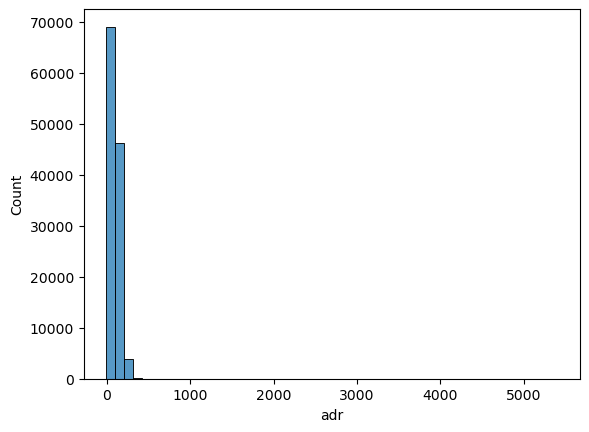

In [5]:
sns.histplot(df["adr"], bins=50)

#### Early Reservations VS Last minute

Text(0.5, 1.0, 'Distribution of Lead Time')

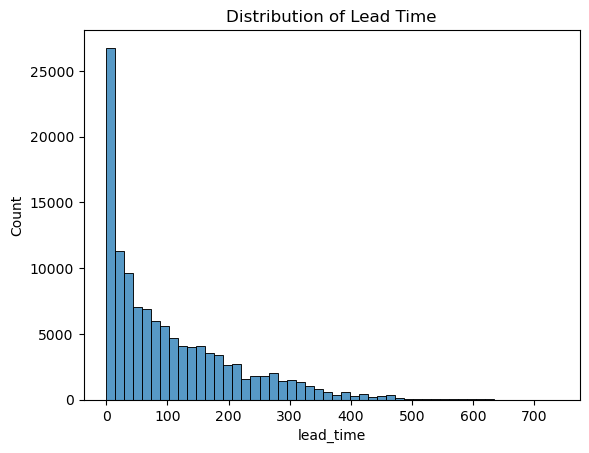

In [6]:
sns.histplot(df["lead_time"], bins=50)
plt.title("Distribution of Lead Time")

#### Country Distribuition

Text(0.5, 1.0, 'Country Distribuition')

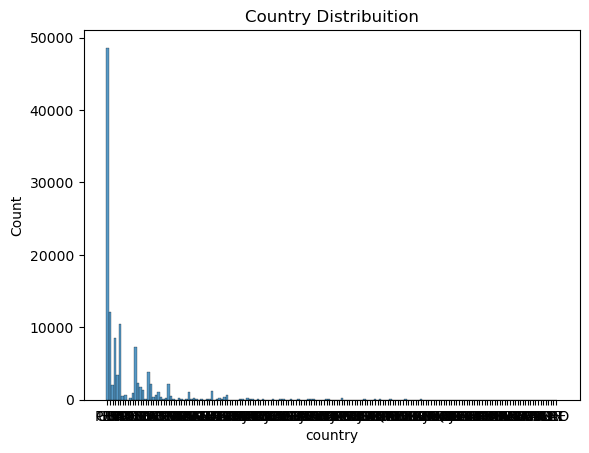

In [7]:
sns.histplot(df["country"], bins=70)
plt.title("Country Distribuition")

#### Price Fluctuation

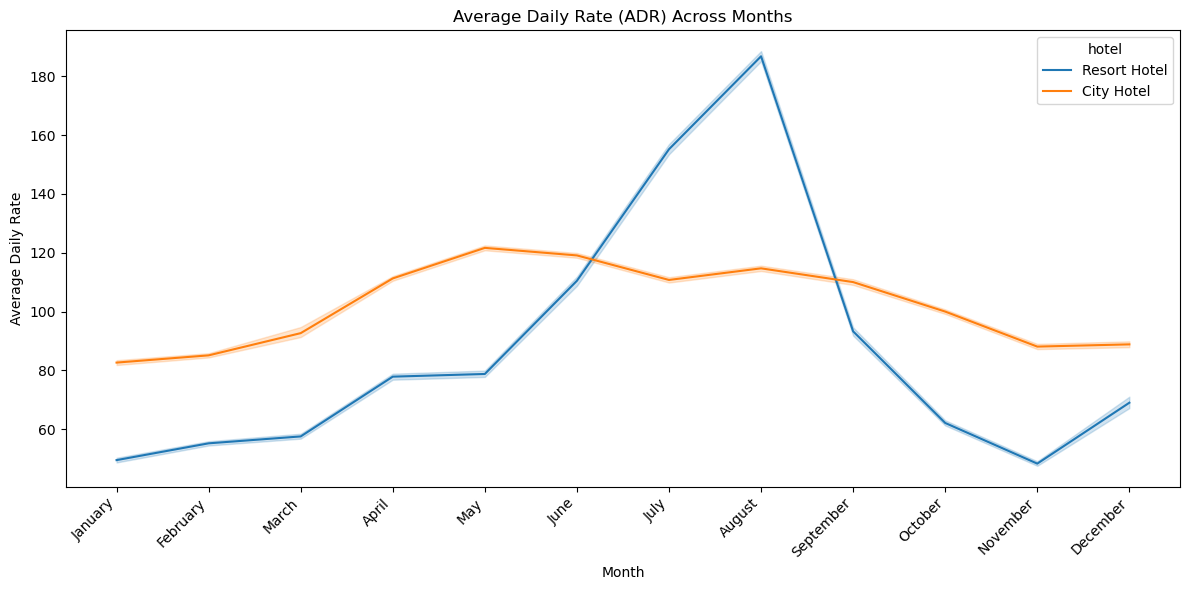

In [8]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']

# Convert the column to an ordered categorical type
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=months, ordered=True)

plt.figure(figsize=(12, 6))
sns.lineplot(x='arrival_date_month', y='adr', hue='hotel', data=df)

plt.xticks(rotation=45, ha='right') 
plt.title('Average Daily Rate (ADR) Across Months')
plt.ylabel('Average Daily Rate')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

#### Market Segmentation

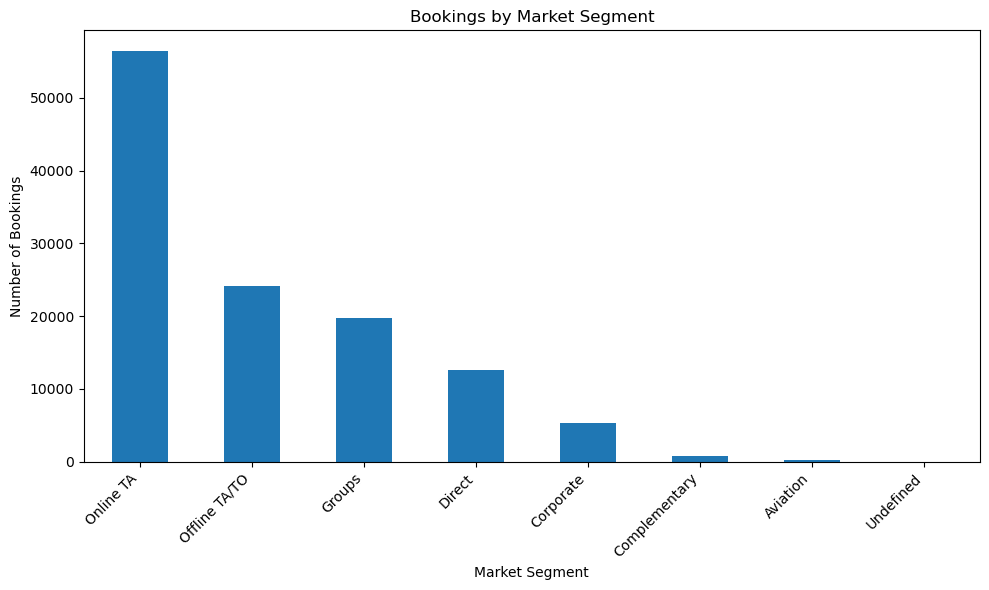

In [9]:
plt.figure(figsize=(10, 6))

market_counts = df['market_segment'].value_counts().plot(kind='bar')

plt.title('Bookings by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

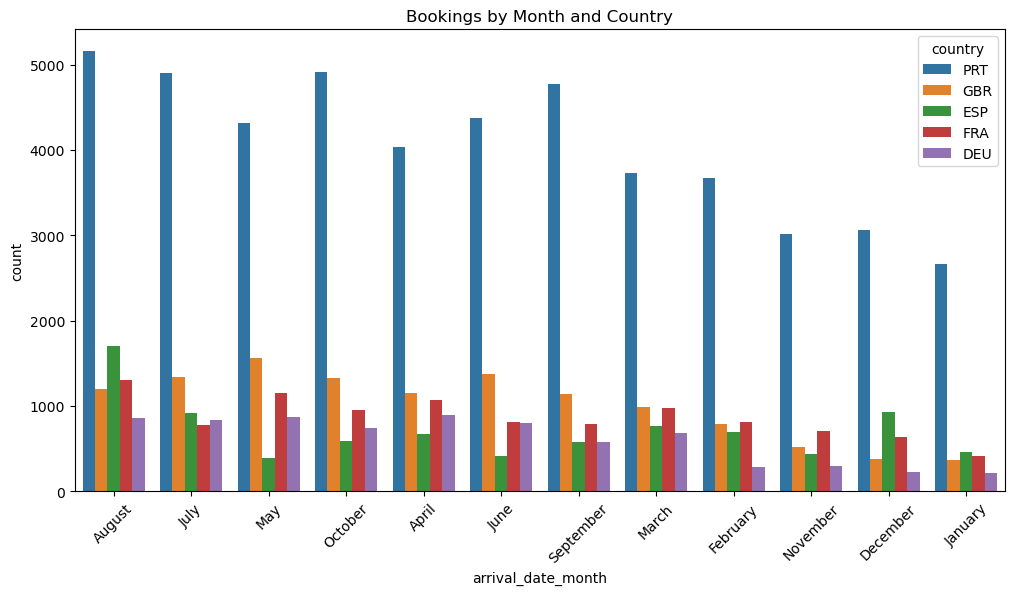

In [10]:
top_countries = df["country"].value_counts().nlargest(5).index

df_top = df[df["country"].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.countplot(data=df_top, x="arrival_date_month", hue="country",
              order=df["arrival_date_month"].value_counts().index)

plt.xticks(rotation=45)
plt.title("Bookings by Month and Country")
plt.show()

Text(0.5, 1.0, 'Lead Time by Country')

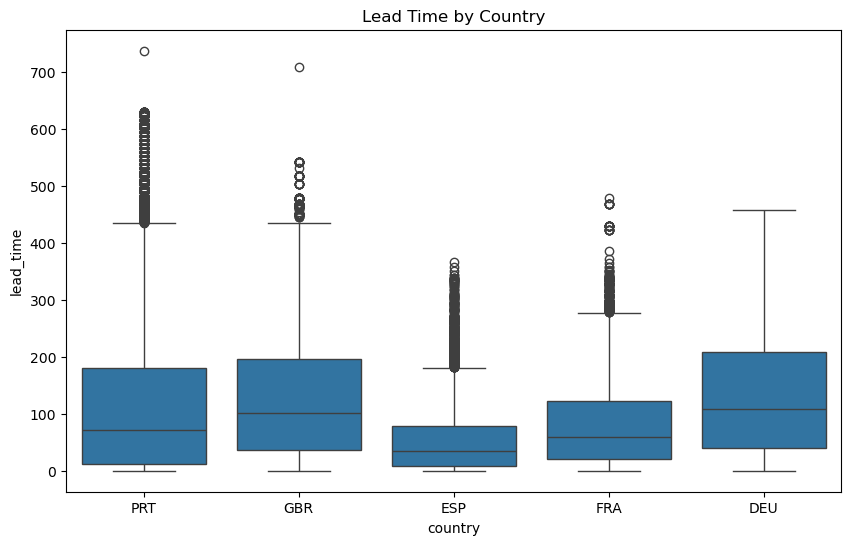

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_top, x="country", y="lead_time")
plt.title("Lead Time by Country")

Text(0.5, 1.0, 'Heatmap: Country vs Month')

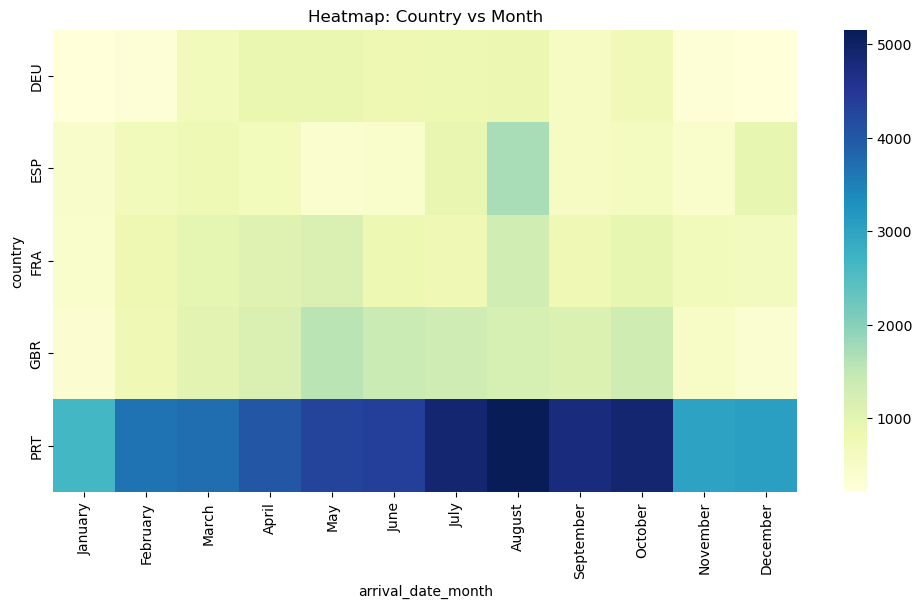

In [12]:
pivot = pd.crosstab(df_top["country"], df_top["arrival_date_month"])

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Heatmap: Country vs Month")

#### Categorical Variables Distribuitions

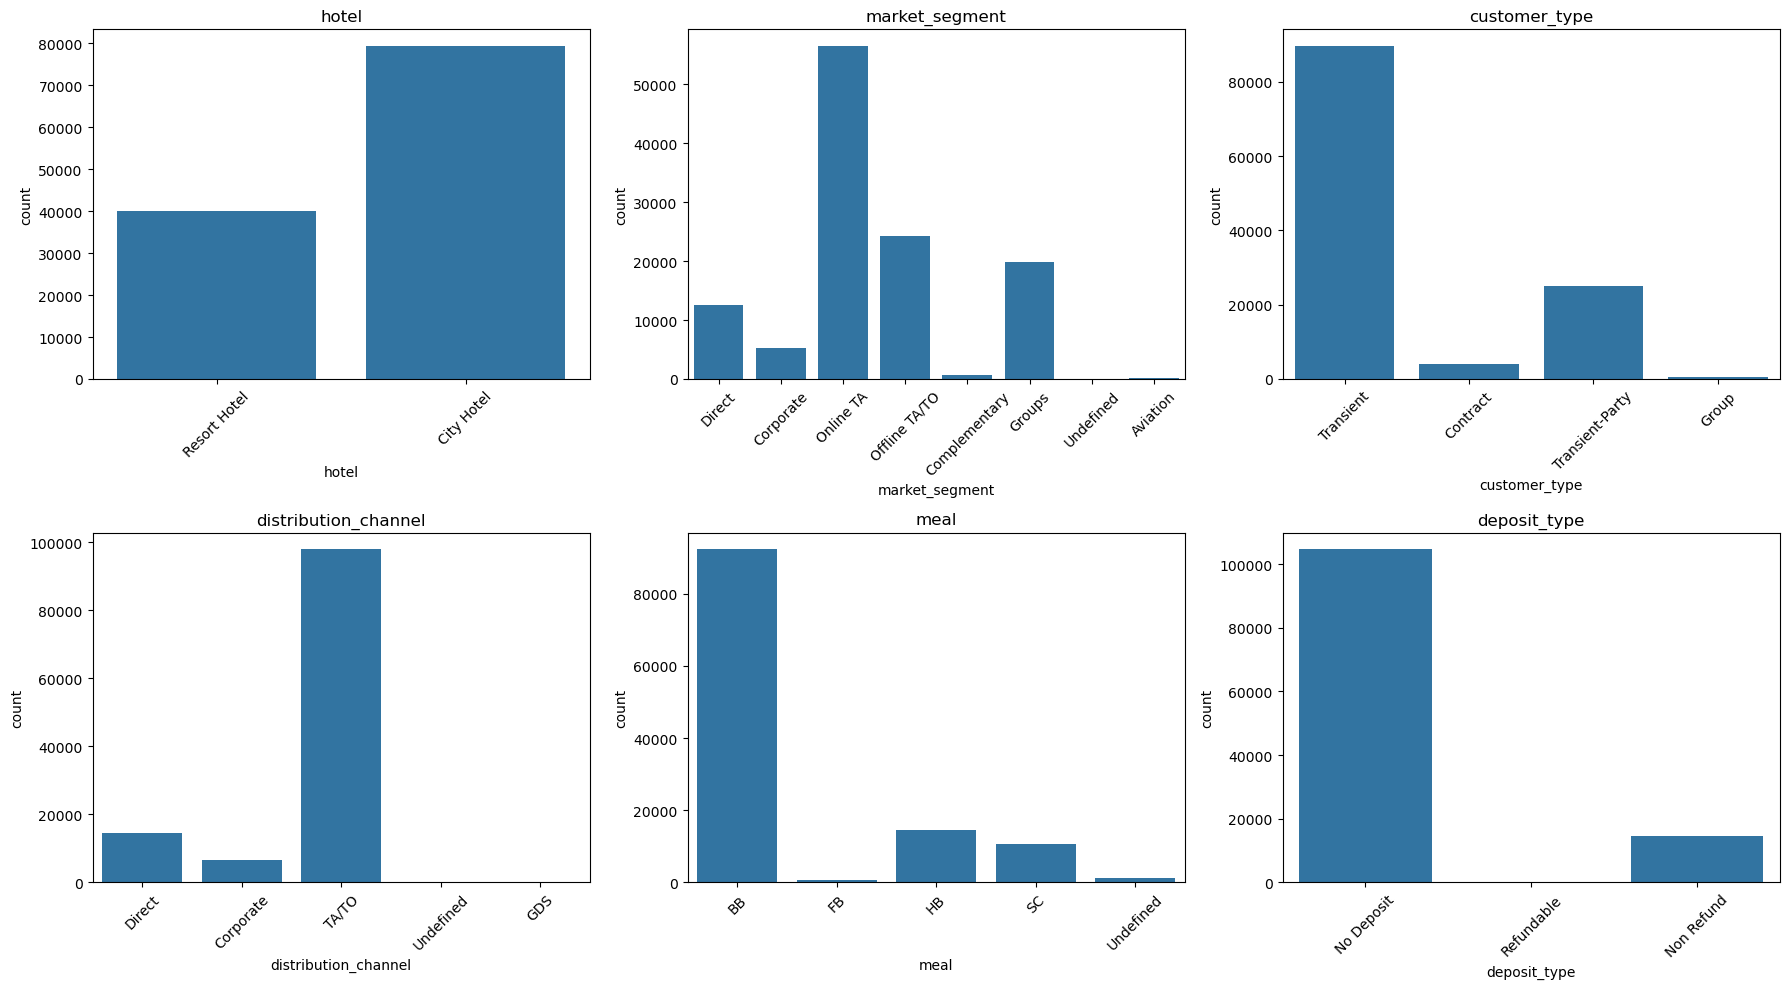

In [13]:
categorical_cols = [
    "hotel",
    "market_segment",
    "customer_type",
    "distribution_channel",
    "meal",
    "deposit_type"
]

fig, axes = plt.subplots(2, 3, figsize=(18,10))

for col, ax in zip(categorical_cols, axes.flatten()):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Reservations by Month

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'August'),
  Text(1, 0, 'July'),
  Text(2, 0, 'May'),
  Text(3, 0, 'October'),
  Text(4, 0, 'April'),
  Text(5, 0, 'June'),
  Text(6, 0, 'September'),
  Text(7, 0, 'March'),
  Text(8, 0, 'February'),
  Text(9, 0, 'November'),
  Text(10, 0, 'December'),
  Text(11, 0, 'January')])

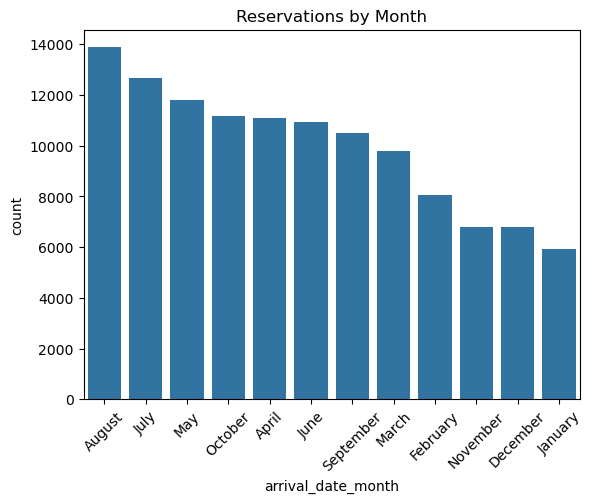

In [14]:
sns.countplot(x="arrival_date_month", data=df,
              order=df["arrival_date_month"].value_counts().index)
plt.title('Reservations by Month')
plt.xticks(rotation=45)

#### Number of Nights

Text(0.5, 1.0, 'Number of Nights')

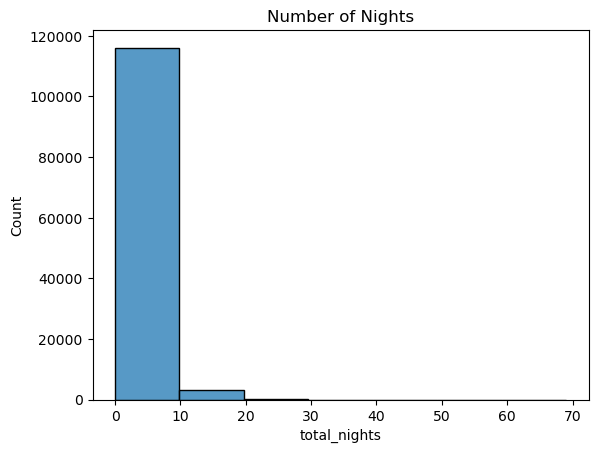

In [15]:
df["total_nights"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]

sns.histplot(df["total_nights"], bins=7)
plt.title('Number of Nights')

#### Lead time vs hotel

<Axes: xlabel='hotel', ylabel='lead_time'>

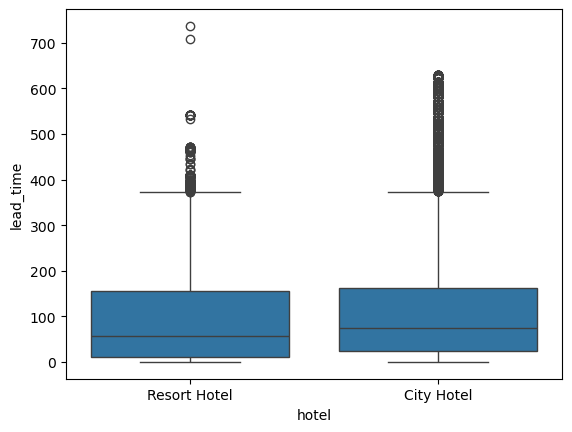

In [16]:
sns.boxplot(x="hotel", y="lead_time", data=df)

#### Cancelations

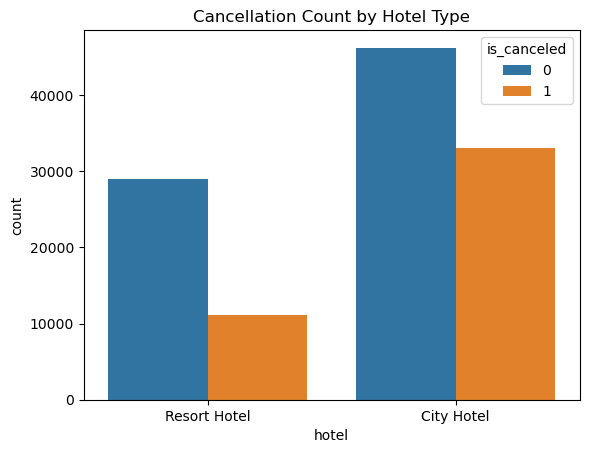

In [17]:
sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.title('Cancellation Count by Hotel Type')
plt.show()

## **Data preprocessing**

#### Delete Variables

In [18]:
# Leakage Control and high cardinality variables
drop_cols = [
    "is_canceled",
    "reservation_status",
    "reservation_status_date",
    "agent",
    "company"
]

df = df.drop(columns=drop_cols)

## **Feature Engineering**

In [19]:
# Arrival Date
date_string = (df['arrival_date_day_of_month'].astype(str) + '-' + df['arrival_date_month'].astype(str) + '-' + df['arrival_date_year'].astype(str))
df['arrival_date'] = pd.to_datetime(date_string, format='%d-%B-%Y')
# df[['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'arrival_date']].head()

# Total Nights
df["total_nights"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]

# Total Guests
df["total_guests"] = (df["adults"] + df["children"].fillna(0) + df["babies"]).astype(int)

# Room change to see upgrades and overbooking
df["room_changed"] = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)

# Group rare countries
top_countries = df["country"].value_counts().nlargest(10).index
df["country_grouped"] = df["country"].apply(lambda x: x if x in top_countries else "Other")

df.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_nights,arrival_date,total_guests,room_changed,country_grouped
0,Resort Hotel,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.0,0,0,0,2015-07-01,2,0,PRT
1,Resort Hotel,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.0,0,0,0,2015-07-01,2,0,PRT
2,Resort Hotel,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.0,0,0,1,2015-07-01,1,1,GBR
3,Resort Hotel,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.0,0,0,1,2015-07-01,1,0,GBR
4,Resort Hotel,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,1,2,2015-07-01,2,0,GBR


## **KMeans Clustering**

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

cluster_features = [
    "adr",
    "total_nights",
    "lead_time",
    "total_of_special_requests",
]

X = df[cluster_features].copy()

k_values = range(2, 11)

results_kmeans = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    silhouette = silhouette_score(X, labels)
    ch_score = calinski_harabasz_score(X, labels)
    db_score = davies_bouldin_score(X, labels)

    results_kmeans.append({
        "model": "kmeans",
        "k": k,
        "silhouette": silhouette,
        "calinski": ch_score,
        "davies": db_score
    })

results_kmeans = pd.DataFrame(results_kmeans)
results_kmeans

,model,k,silhouette,calinski,davies
0,kmeans,2,0.546123,160453.318941,0.693444
1,kmeans,3,0.447286,143401.756773,0.803581
2,kmeans,4,0.417844,141282.802784,0.814801
3,kmeans,5,0.407820,134629.215050,0.796573
4,kmeans,6,0.388031,130910.524669,0.806893
5,kmeans,7,0.376133,129273.421797,0.825465
6,kmeans,8,0.376233,128369.197864,0.723461
7,kmeans,9,0.375236,130147.436655,0.723677
8,kmeans,10,0.356156,128815.532132,0.748866


## **Second Clustering Algorithm**

In [21]:
from sklearn.mixture import GaussianMixture

k_values = range(2, 11)

results_gmm = []

for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X)

    silhouette = silhouette_score(X, labels)
    ch_score = calinski_harabasz_score(X, labels)
    db_score = davies_bouldin_score(X, labels)

    results_gmm.append({
        "model": "gmm",
        "k": k,
        "silhouette": silhouette,
        "calinski": ch_score,
        "davies": db_score
    })

results_gmm = pd.DataFrame(results_gmm)
results_gmm

,model,k,silhouette,calinski,davies
0,gmm,2,0.404814,93630.534800,0.928084
1,gmm,3,-0.089528,8979.237336,3.421684
2,gmm,4,-0.066681,660.397323,14.945927
3,gmm,5,-0.177419,3417.721102,9.190270
4,gmm,6,-0.255045,1140.635992,8.570604
5,gmm,7,-0.242819,2815.356328,8.908622
6,gmm,8,-0.211455,2940.353103,10.556632
7,gmm,9,-0.249113,1895.594777,6.865503
8,gmm,10,-0.249277,1851.285681,8.687960


## **Evaluations Metrics**

In [ ]:
results_all = pd.concat([results_kmeans, results_gmm])
results_all.to_csv("experiments.csv", index=False)

,model,k,silhouette,calinski,davies
0,kmeans,2,0.546123,160453.318941,0.693444
1,kmeans,3,0.447286,143401.756773,0.803581
2,kmeans,4,0.417844,141282.802784,0.814801
3,kmeans,5,0.407820,134629.215050,0.796573
4,kmeans,6,0.388031,130910.524669,0.806893


<Axes: xlabel='k', ylabel='silhouette'>

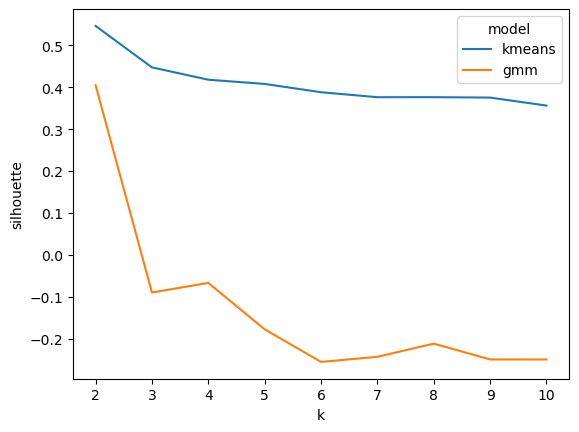

In [23]:
sns.lineplot(data=results_all, x="k", y="silhouette", hue="model")

## **Stability Analysis**

In [27]:
from sklearn.metrics import adjusted_rand_score

seeds = [0, 1, 2, 3, 4]

stability_scores = []

for k in [2, 3, 4, 5]:  # choose best k candidates
    labels_list = []

    for seed in seeds:
        kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = kmeans.fit_predict(X)
        labels_list.append(labels)

    # Compare all pairs
    ari_scores = []
    for i in range(len(labels_list)):
        for j in range(i+1, len(labels_list)):
            ari = adjusted_rand_score(labels_list[i], labels_list[j])
            ari_scores.append(ari)

    stability_scores.append({
        "k": k,
        "mean_ari": np.mean(ari_scores),
        "std_ari": np.std(ari_scores)
    })

stability_df = pd.DataFrame(stability_scores)
stability_df

,k,mean_ari,std_ari
0,2,0.999407,0.000457
1,3,0.999516,0.000449
2,4,0.996491,0.001824
3,5,0.996703,0.003747


## **Sensitivity Analysis**

In [25]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scalers = {
    "standard": StandardScaler(),
    "robust": RobustScaler()
}

sensitivity_results = []

for name, scaler in scalers.items():
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)

    sensitivity_results.append({
        "scaler": name,
        "silhouette": silhouette
    })

pd.DataFrame(sensitivity_results)

,scaler,silhouette
0,standard,0.283322
1,robust,0.251075


## **Cluster Interpretation**

In [33]:
best_k = 2
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

df["cluster"] = labels

# Numeric profile
cluster_profile_num = df.groupby("cluster").mean(numeric_only=True)

# Categorical profile
cat_cols = df.select_dtypes(include=["object", "string"]).columns
cluster_profile_cat = df.groupby("cluster")[cat_cols].agg(lambda x: x.mode()[0] if not x.mode().empty else None)

print("Numerical profile:")
display(cluster_profile_num)

print("Categorical profile:")
display(cluster_profile_cat)

Numerical profile:


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,room_changed
cluster,,,,,,,,,,,,,,,,,,,,
0,49.052925,2016.140631,26.161314,15.824209,0.877388,2.318487,1.829146,0.111174,0.008848,0.040409,0.037075,0.182597,0.214897,0.765042,103.690825,0.075005,0.607858,3.195875,1.949163,0.146710
1,249.697970,2016.198765,29.826249,15.729405,1.060700,2.982264,1.928659,0.084582,0.005565,0.009388,0.219772,0.016482,0.237631,6.446150,96.901332,0.029417,0.474619,4.042964,2.018806,0.067244


Categorical profile:


,hotel,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,country_grouped
cluster,,,,,,,,,,
0,City Hotel,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,PRT
1,City Hotel,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,PRT
